In [1]:
import numpy as np
import pymc as pm
import arviz as az
# -- use this line at the beginning of your notebook to turn on interactive plots
%matplotlib notebook
import scipy.io
# note these imports, thay may be useful in your own task

import matplotlib.pyplot as plt  # plotting library
import numpy as np  # work with numeric arrays without labeled axes
import xarray as xr  # work with arrays with labeled axes
import pandas as pd

In [45]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19


df.loc[:, 'TOK'] = df['TOK'].str.strip()

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))

# 如果需要查看分类结果
print(df)



      TOK        SHOT      TIME PHASE  PGASA      RGEO      AMIN    KAPPA  \
0    CMOD  1050428004   0.63461    LH  2.000  0.672389  0.216421  1.69737   
1    CMOD  1050428007   0.66603    LH  2.000  0.670773  0.217660  1.67073   
2    CMOD  1050621015   0.91039    LH  2.000  0.672785  0.217388  1.67962   
3    CMOD  1050621029   0.85420    LH  2.000  0.670869  0.217080  1.69789   
4    CMOD  1050623008   0.80070    LH  2.000  0.678764  0.213690  1.44202   
..    ...         ...       ...   ...    ...       ...       ...      ...   
685   JET       90527  50.99500    LH  1.962  2.900090  0.933780  1.66731   
686   JET       90528  55.16500    LH  1.916  2.901440  0.933319  1.66831   
687   JET       90737  54.56500    LH  1.940  2.901330  0.934255  1.66599   
688   JET       90738  54.46500    LH  1.961  2.898400  0.937640  1.65848   
689   JET       90742  52.16500    LH  1.983  2.900930  0.933565  1.66813   

       SPLASMA CONFIG  ...       PL     PLTH    PFLOSS PRADCORE    DIVCON  

In [3]:


# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})
x = df['NEL']
y = df['PLTH']
bt = df['BT'].abs()
ip= df['IP']

# 分类 BT 值
subset2_2 = df[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (df['Category'] == 'Deuterium')& (df['DIVCON'] == 'VT')]
df = df.drop(subset2_2.index)
print(df)

      TOK        SHOT      TIME PHASE  PGASA      RGEO      AMIN    KAPPA  \
0    CMOD  1050428004   0.63461    LH  2.000  0.672389  0.216421  1.69737   
1    CMOD  1050428007   0.66603    LH  2.000  0.670773  0.217660  1.67073   
2    CMOD  1050621015   0.91039    LH  2.000  0.672785  0.217388  1.67962   
3    CMOD  1050621029   0.85420    LH  2.000  0.670869  0.217080  1.69789   
4    CMOD  1050623008   0.80070    LH  2.000  0.678764  0.213690  1.44202   
..    ...         ...       ...   ...    ...       ...       ...      ...   
685   JET       90527  50.99500    LH  1.962  2.900090  0.933780  1.66731   
686   JET       90528  55.16500    LH  1.916  2.901440  0.933319  1.66831   
687   JET       90737  54.56500    LH  1.940  2.901330  0.934255  1.66599   
688   JET       90738  54.46500    LH  1.961  2.898400  0.937640  1.65848   
689   JET       90742  52.16500    LH  1.983  2.900930  0.933565  1.66813   

       SPLASMA CONFIG  ...       PL     PLTH    PFLOSS PRADCORE    DIVCON  

In [5]:
import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','BT','IP','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[df['SELEC2024'] == 1][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/new_df['SPLASMA']/2
# 显示新 DataFrame
print("New DataFrame:")
print(new_df)


columns_to_include_for_regre = ['BP','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BP','NEL','PGASA']] 
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop([' VERTPLT','V5'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','HT3R']].max(axis=1)
x.drop(['HT3R','V5E','V5C','STANDARD'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

New DataFrame:
      TOK    SPLASMA       BT        IP      RGEO     PLTH    NEL  PGASA  \
0    CMOD    7.42158  5.33923  0.931812  0.672389  2.28952  19.70  2.000   
2    CMOD    7.37796  5.32586  0.634247  0.672785  1.42493  18.90  2.000   
3    CMOD    7.43647  5.33346  1.030660  0.670869  1.37273  16.20  2.000   
4    CMOD    6.70529  5.26510  0.681653  0.678764  1.79110  22.00  2.000   
5    CMOD    6.70899  5.26576  0.660100  0.678854  1.81159  21.50  2.000   
..    ...        ...      ...       ...       ...      ...    ...    ...   
679   JET  138.89300  2.94982  2.466400  2.900350  7.87774   3.65  1.922   
680   JET  138.67000  2.93182  3.154820  2.908120  7.33348   3.28  1.925   
683   JET  138.41700  2.95200  2.168050  2.898780  7.39600   3.22  1.915   
684   JET  138.57200  2.94335  2.806420  2.904780  9.08634   3.26  1.904   
686   JET  138.53000  3.31544  2.467660  2.901440  8.96516   3.37  1.916   

       DIVCON        BP  PLTH/S/2  
0     VERTPLT  0.666565  0.154247  


Sequential sampling (4 chains in 1 job)
CompoundStep
>NUTS: [alpha, p, eta, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 493 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 2829 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


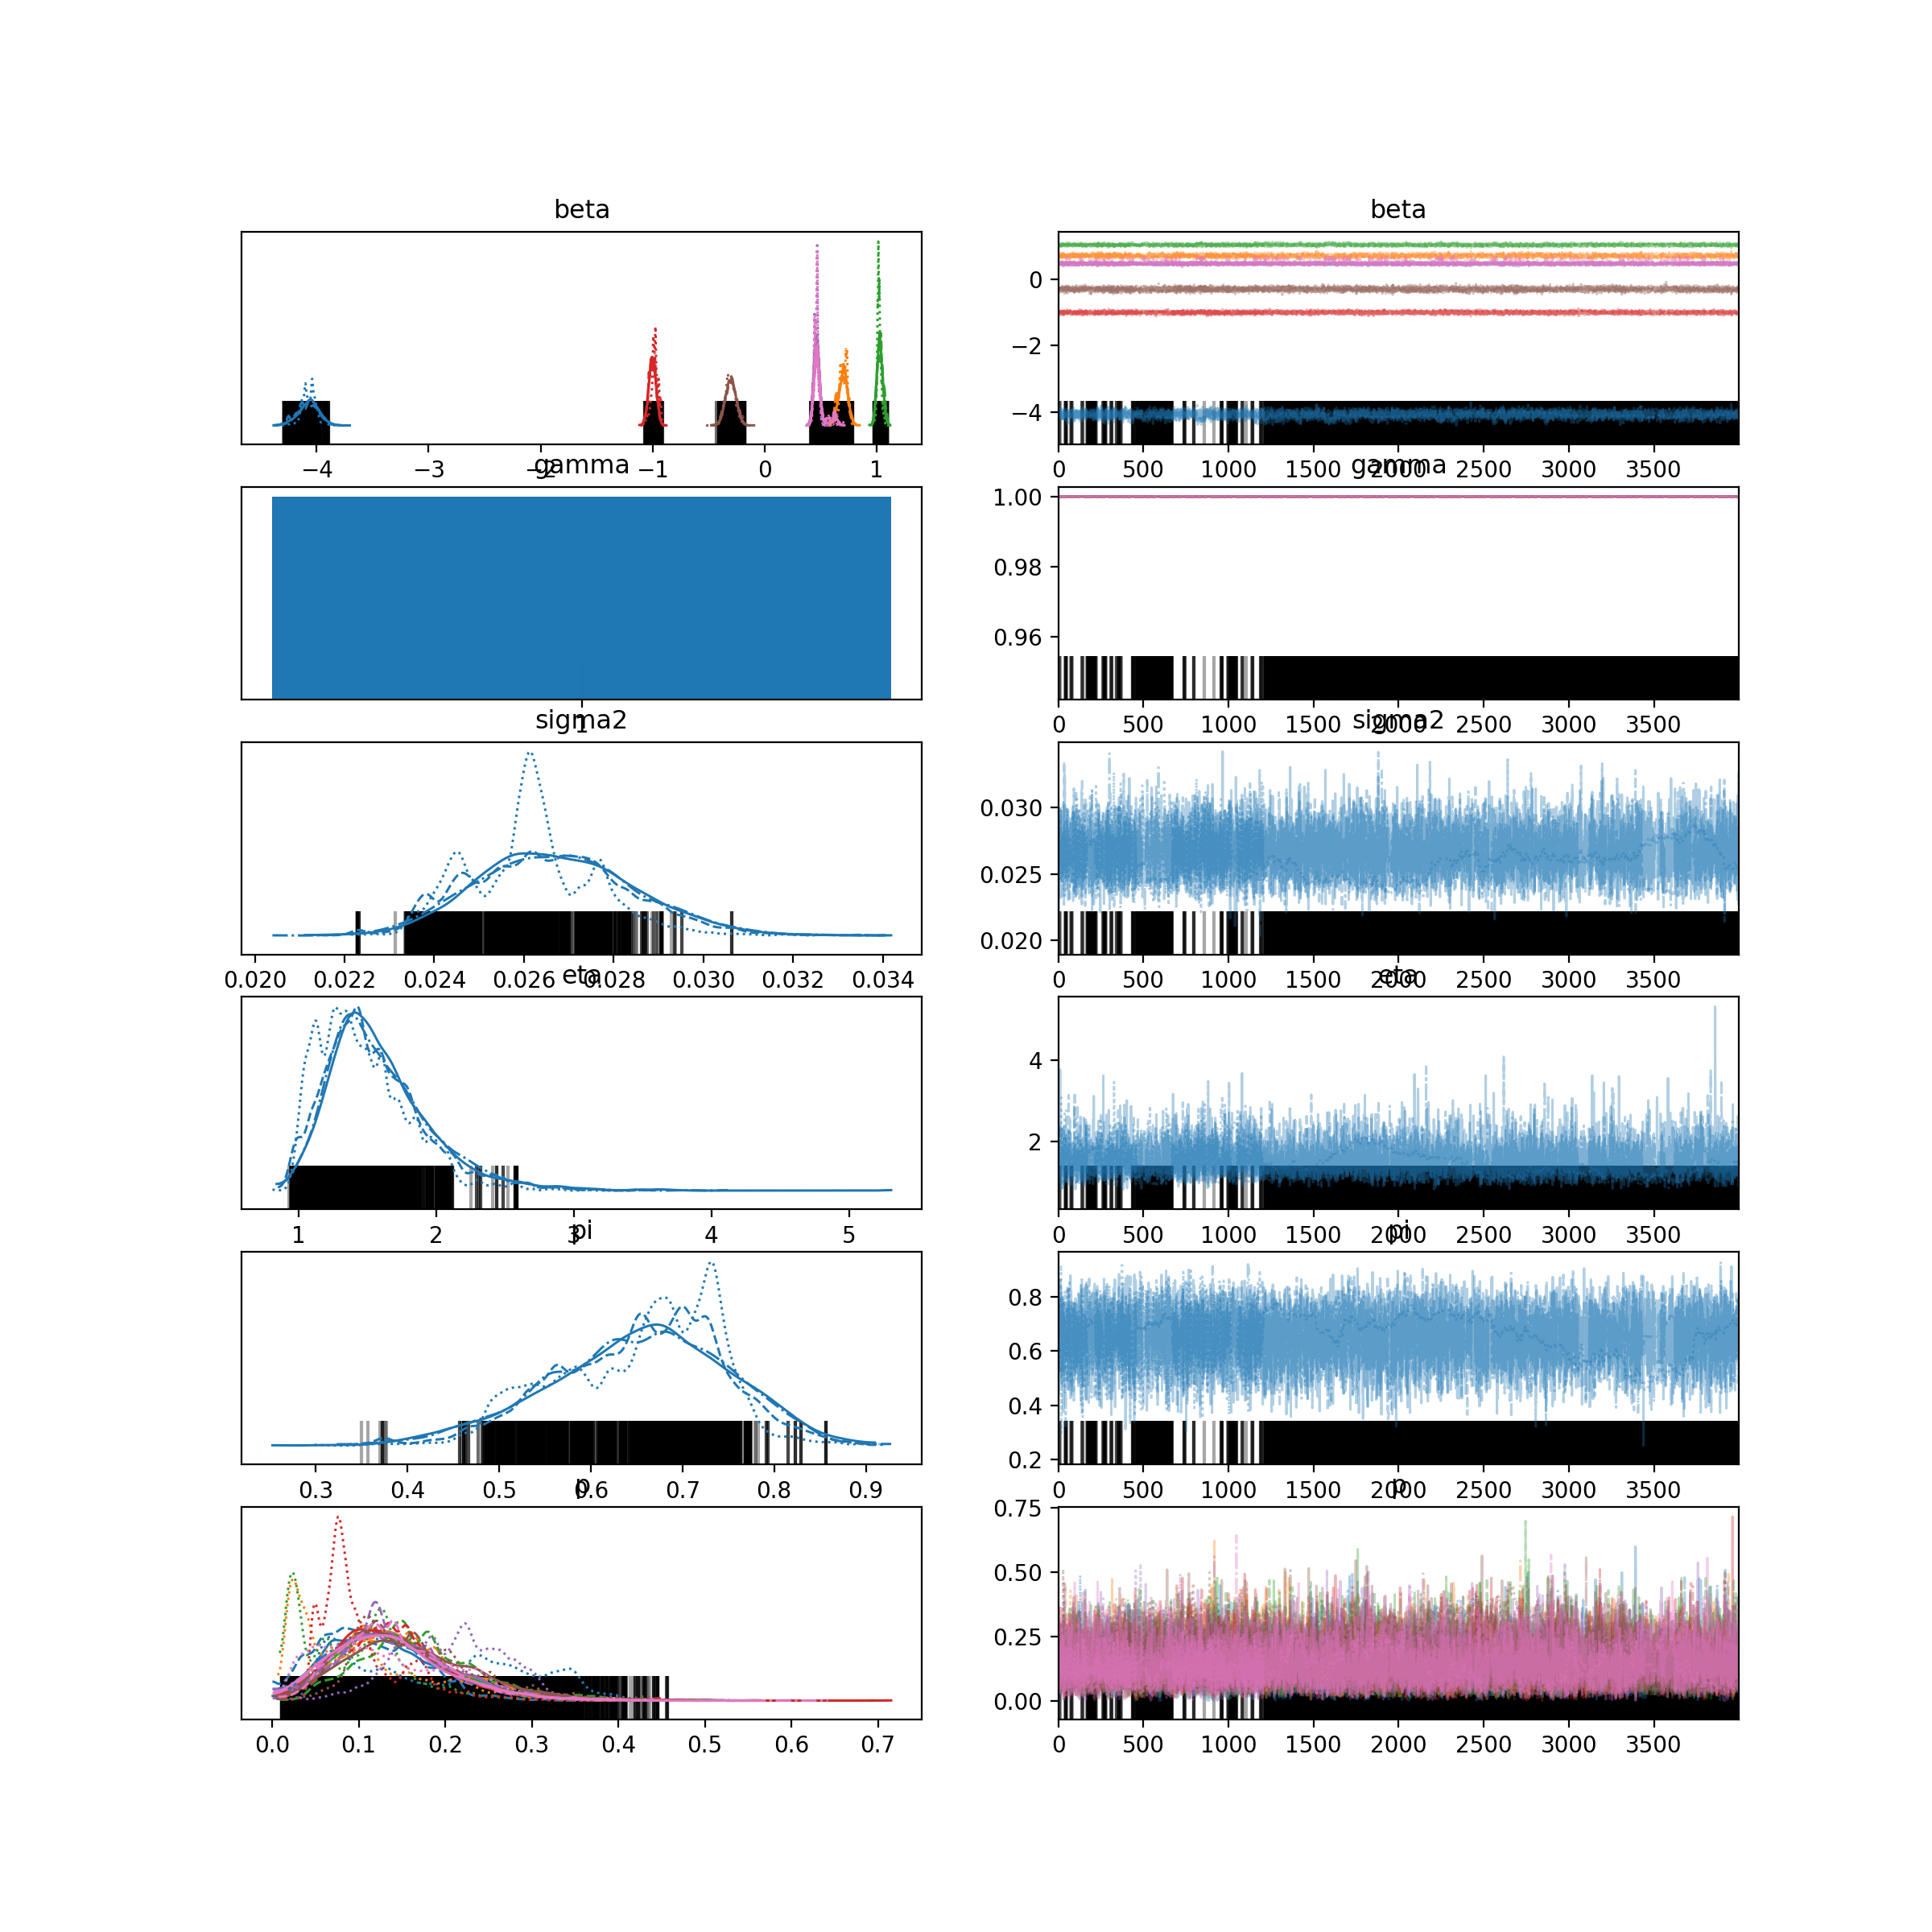

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  -4.073  0.087  -4.254   -3.916      0.003    0.002     604.0   
beta[1]   0.699  0.040   0.622    0.770      0.002    0.002     301.0   
beta[2]   1.027  0.025   0.982    1.077      0.001    0.001     526.0   
beta[3]  -0.997  0.033  -1.056   -0.931      0.005    0.004      40.0   
beta[4]   0.462  0.023   0.419    0.506      0.001    0.001     642.0   
beta[5]  -0.304  0.047  -0.396   -0.220      0.001    0.001    2304.0   
beta[6]   0.481  0.053   0.413    0.620      0.002    0.002     356.0   
gamma[0]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[1]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[2]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[3]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[4]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[5]  1.000  0.000   1.000    1.000      0.000 

In [10]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 4000  # Number of samples
D = 7  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=3.0)  # Dirichlet prior concentration parameter
    #alpha=5
    p = pm.Dirichlet("p", a=pm.math.ones(7) * alpha, shape=7)  # Class probabilities

    S = pm.Categorical("S", p=p, shape=D)  # Class assignment for predictors (0-9)

    eta = pm.InverseGamma("eta", alpha=8.0, beta=8.0)  # Variance for beta_m
    beta_m = pm.Normal("beta_m", mu=0.0, sigma=eta, shape=7)  # Regression coefficients for each class

    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S

    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=8.0, beta=8.0)  # Probability of gamma=1
    gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=0.1, beta=0.1)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=1000, chains=4,step=pm.NUTS(target_accept=0.7,max_treedepth=15), return_inferencedata=True, cores=1)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
print(summary)

<IPython.core.display.Javascript object>


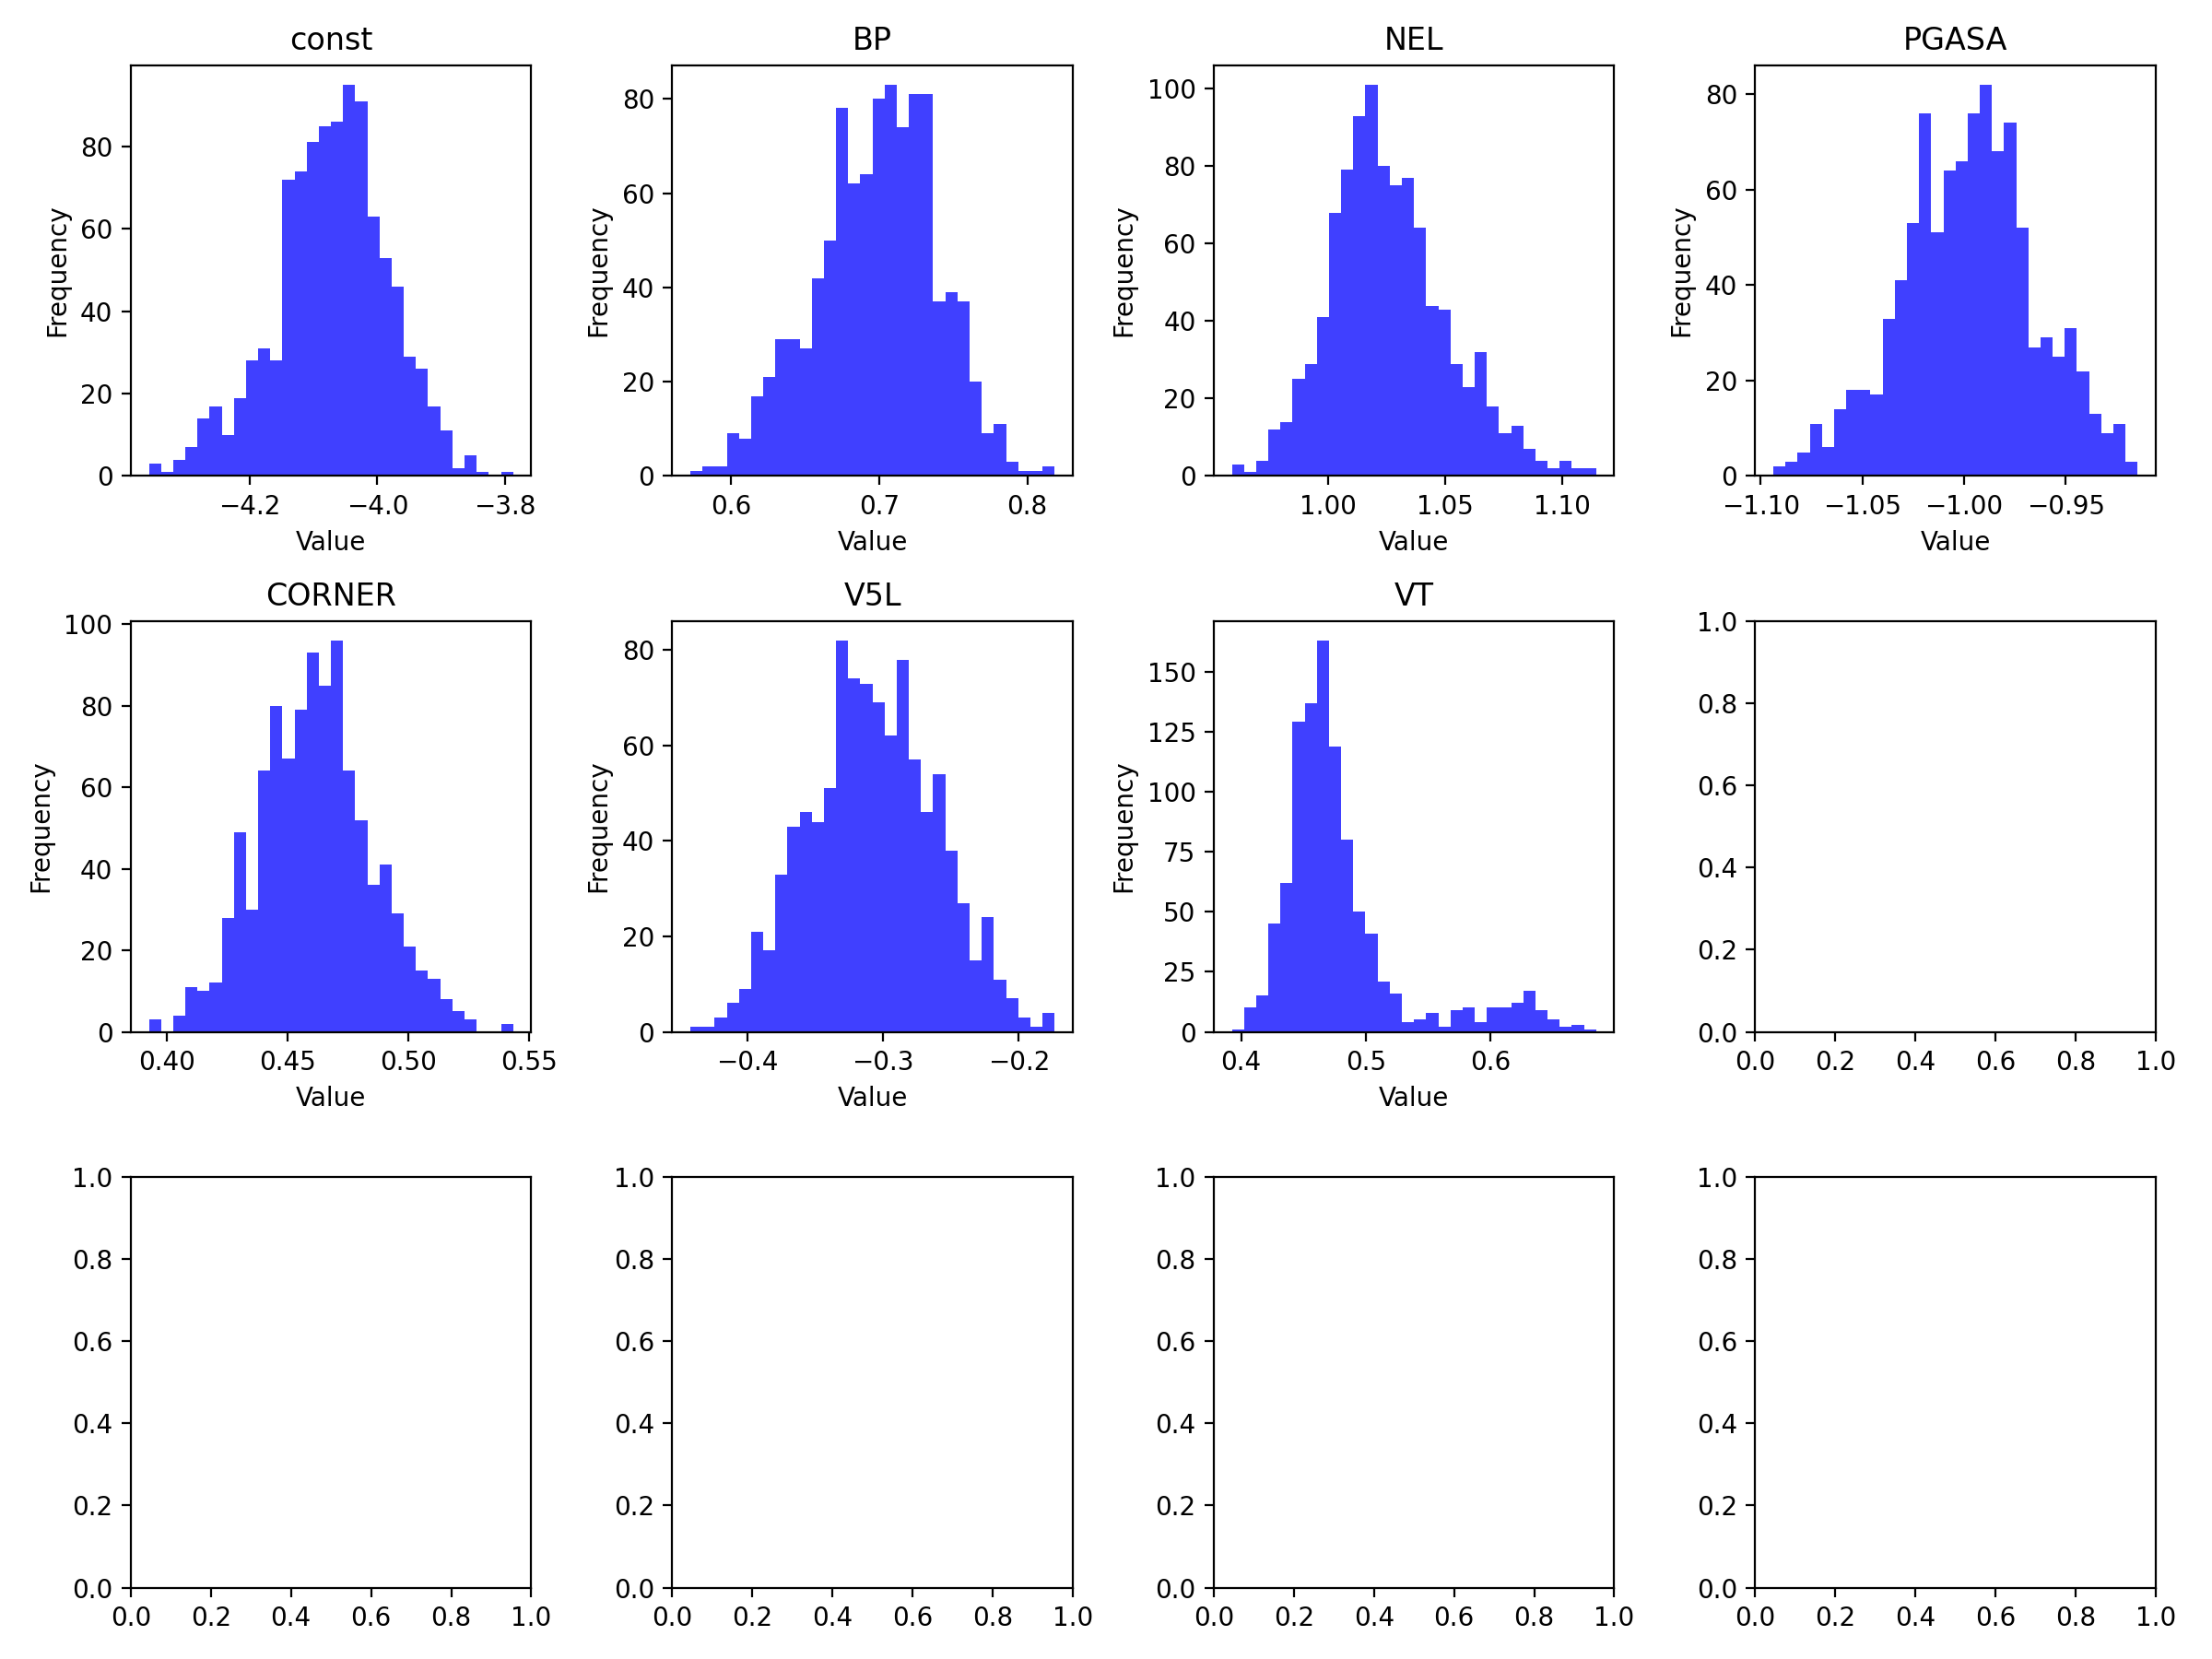

[1. 1. 1. 1. 1. 1. 1.]
[-4.07138001  0.69860888  1.02595785 -0.99764221  0.46159921 -0.30724387
  0.48002879]
[2.173 2.876 3.554 3.094 3.436 3.786 3.31 ]
1000 samples' R² values=: 0.9651


In [11]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))
axes = axes.flatten()

for i in range(7):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [12]:

trace.to_netcdf("my_trace_drop_highVT.nc")

# 查看并保存summary
summary_df = az.summary(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
print(summary_df)
summary_df.to_csv("my_summary.csv")

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  -4.073  0.087  -4.254   -3.916      0.003    0.002     604.0   
beta[1]   0.699  0.040   0.622    0.770      0.002    0.002     301.0   
beta[2]   1.027  0.025   0.982    1.077      0.001    0.001     526.0   
beta[3]  -0.997  0.033  -1.056   -0.931      0.005    0.004      40.0   
beta[4]   0.462  0.023   0.419    0.506      0.001    0.001     642.0   
beta[5]  -0.304  0.047  -0.396   -0.220      0.001    0.001    2304.0   
beta[6]   0.481  0.053   0.413    0.620      0.002    0.002     356.0   
gamma[0]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[1]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[2]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[3]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[4]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[5]  1.000  0.000   1.000    1.000      0.000 

In [15]:


# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})
x = df['NEL']
y = df['PLTH']
bt = df['BT'].abs()
ip= df['IP']

# 分类 BT 值
subset2_3 = df[(ip < 2.3) & (ip >=1.7)&(bt < 2.6) & (bt >=2.0)& (df['Category'] == 'Deuterium')& ((df['DIVCON'] == 'VT')|(df['DIVCON'] == 'CORNER'))]
df = df.drop(subset2_3.index)
print(df)

      TOK        SHOT      TIME PHASE  PGASA      RGEO      AMIN    KAPPA  \
0    CMOD  1050428004   0.63461    LH  2.000  0.672389  0.216421  1.69737   
1    CMOD  1050428007   0.66603    LH  2.000  0.670773  0.217660  1.67073   
2    CMOD  1050621015   0.91039    LH  2.000  0.672785  0.217388  1.67962   
3    CMOD  1050621029   0.85420    LH  2.000  0.670869  0.217080  1.69789   
4    CMOD  1050623008   0.80070    LH  2.000  0.678764  0.213690  1.44202   
..    ...         ...       ...   ...    ...       ...       ...      ...   
685   JET       90527  50.99500    LH  1.962  2.900090  0.933780  1.66731   
686   JET       90528  55.16500    LH  1.916  2.901440  0.933319  1.66831   
687   JET       90737  54.56500    LH  1.940  2.901330  0.934255  1.66599   
688   JET       90738  54.46500    LH  1.961  2.898400  0.937640  1.65848   
689   JET       90742  52.16500    LH  1.983  2.900930  0.933565  1.66813   

       SPLASMA CONFIG  ...       PL     PLTH    PFLOSS PRADCORE    DIVCON  

In [16]:
import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','BT','IP','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[df['SELEC2024'] == 1][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/new_df['SPLASMA']/2
# 显示新 DataFrame
print("New DataFrame:")
print(new_df)


columns_to_include_for_regre = ['BP','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BP','NEL','PGASA']] 
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop([' VERTPLT','V5'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','HT3R']].max(axis=1)
x.drop(['HT3R','V5E','V5C','STANDARD'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

New DataFrame:
      TOK    SPLASMA       BT        IP      RGEO     PLTH    NEL  PGASA  \
0    CMOD    7.42158  5.33923  0.931812  0.672389  2.28952  19.70  2.000   
2    CMOD    7.37796  5.32586  0.634247  0.672785  1.42493  18.90  2.000   
3    CMOD    7.43647  5.33346  1.030660  0.670869  1.37273  16.20  2.000   
4    CMOD    6.70529  5.26510  0.681653  0.678764  1.79110  22.00  2.000   
5    CMOD    6.70899  5.26576  0.660100  0.678854  1.81159  21.50  2.000   
..    ...        ...      ...       ...       ...      ...    ...    ...   
679   JET  138.89300  2.94982  2.466400  2.900350  7.87774   3.65  1.922   
680   JET  138.67000  2.93182  3.154820  2.908120  7.33348   3.28  1.925   
683   JET  138.41700  2.95200  2.168050  2.898780  7.39600   3.22  1.915   
684   JET  138.57200  2.94335  2.806420  2.904780  9.08634   3.26  1.904   
686   JET  138.53000  3.31544  2.467660  2.901440  8.96516   3.37  1.916   

       DIVCON        BP  PLTH/S/2  
0     VERTPLT  0.666565  0.154247  


Sequential sampling (4 chains in 1 job)
CompoundStep
>NUTS: [alpha, p, eta, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 160 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 2309 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


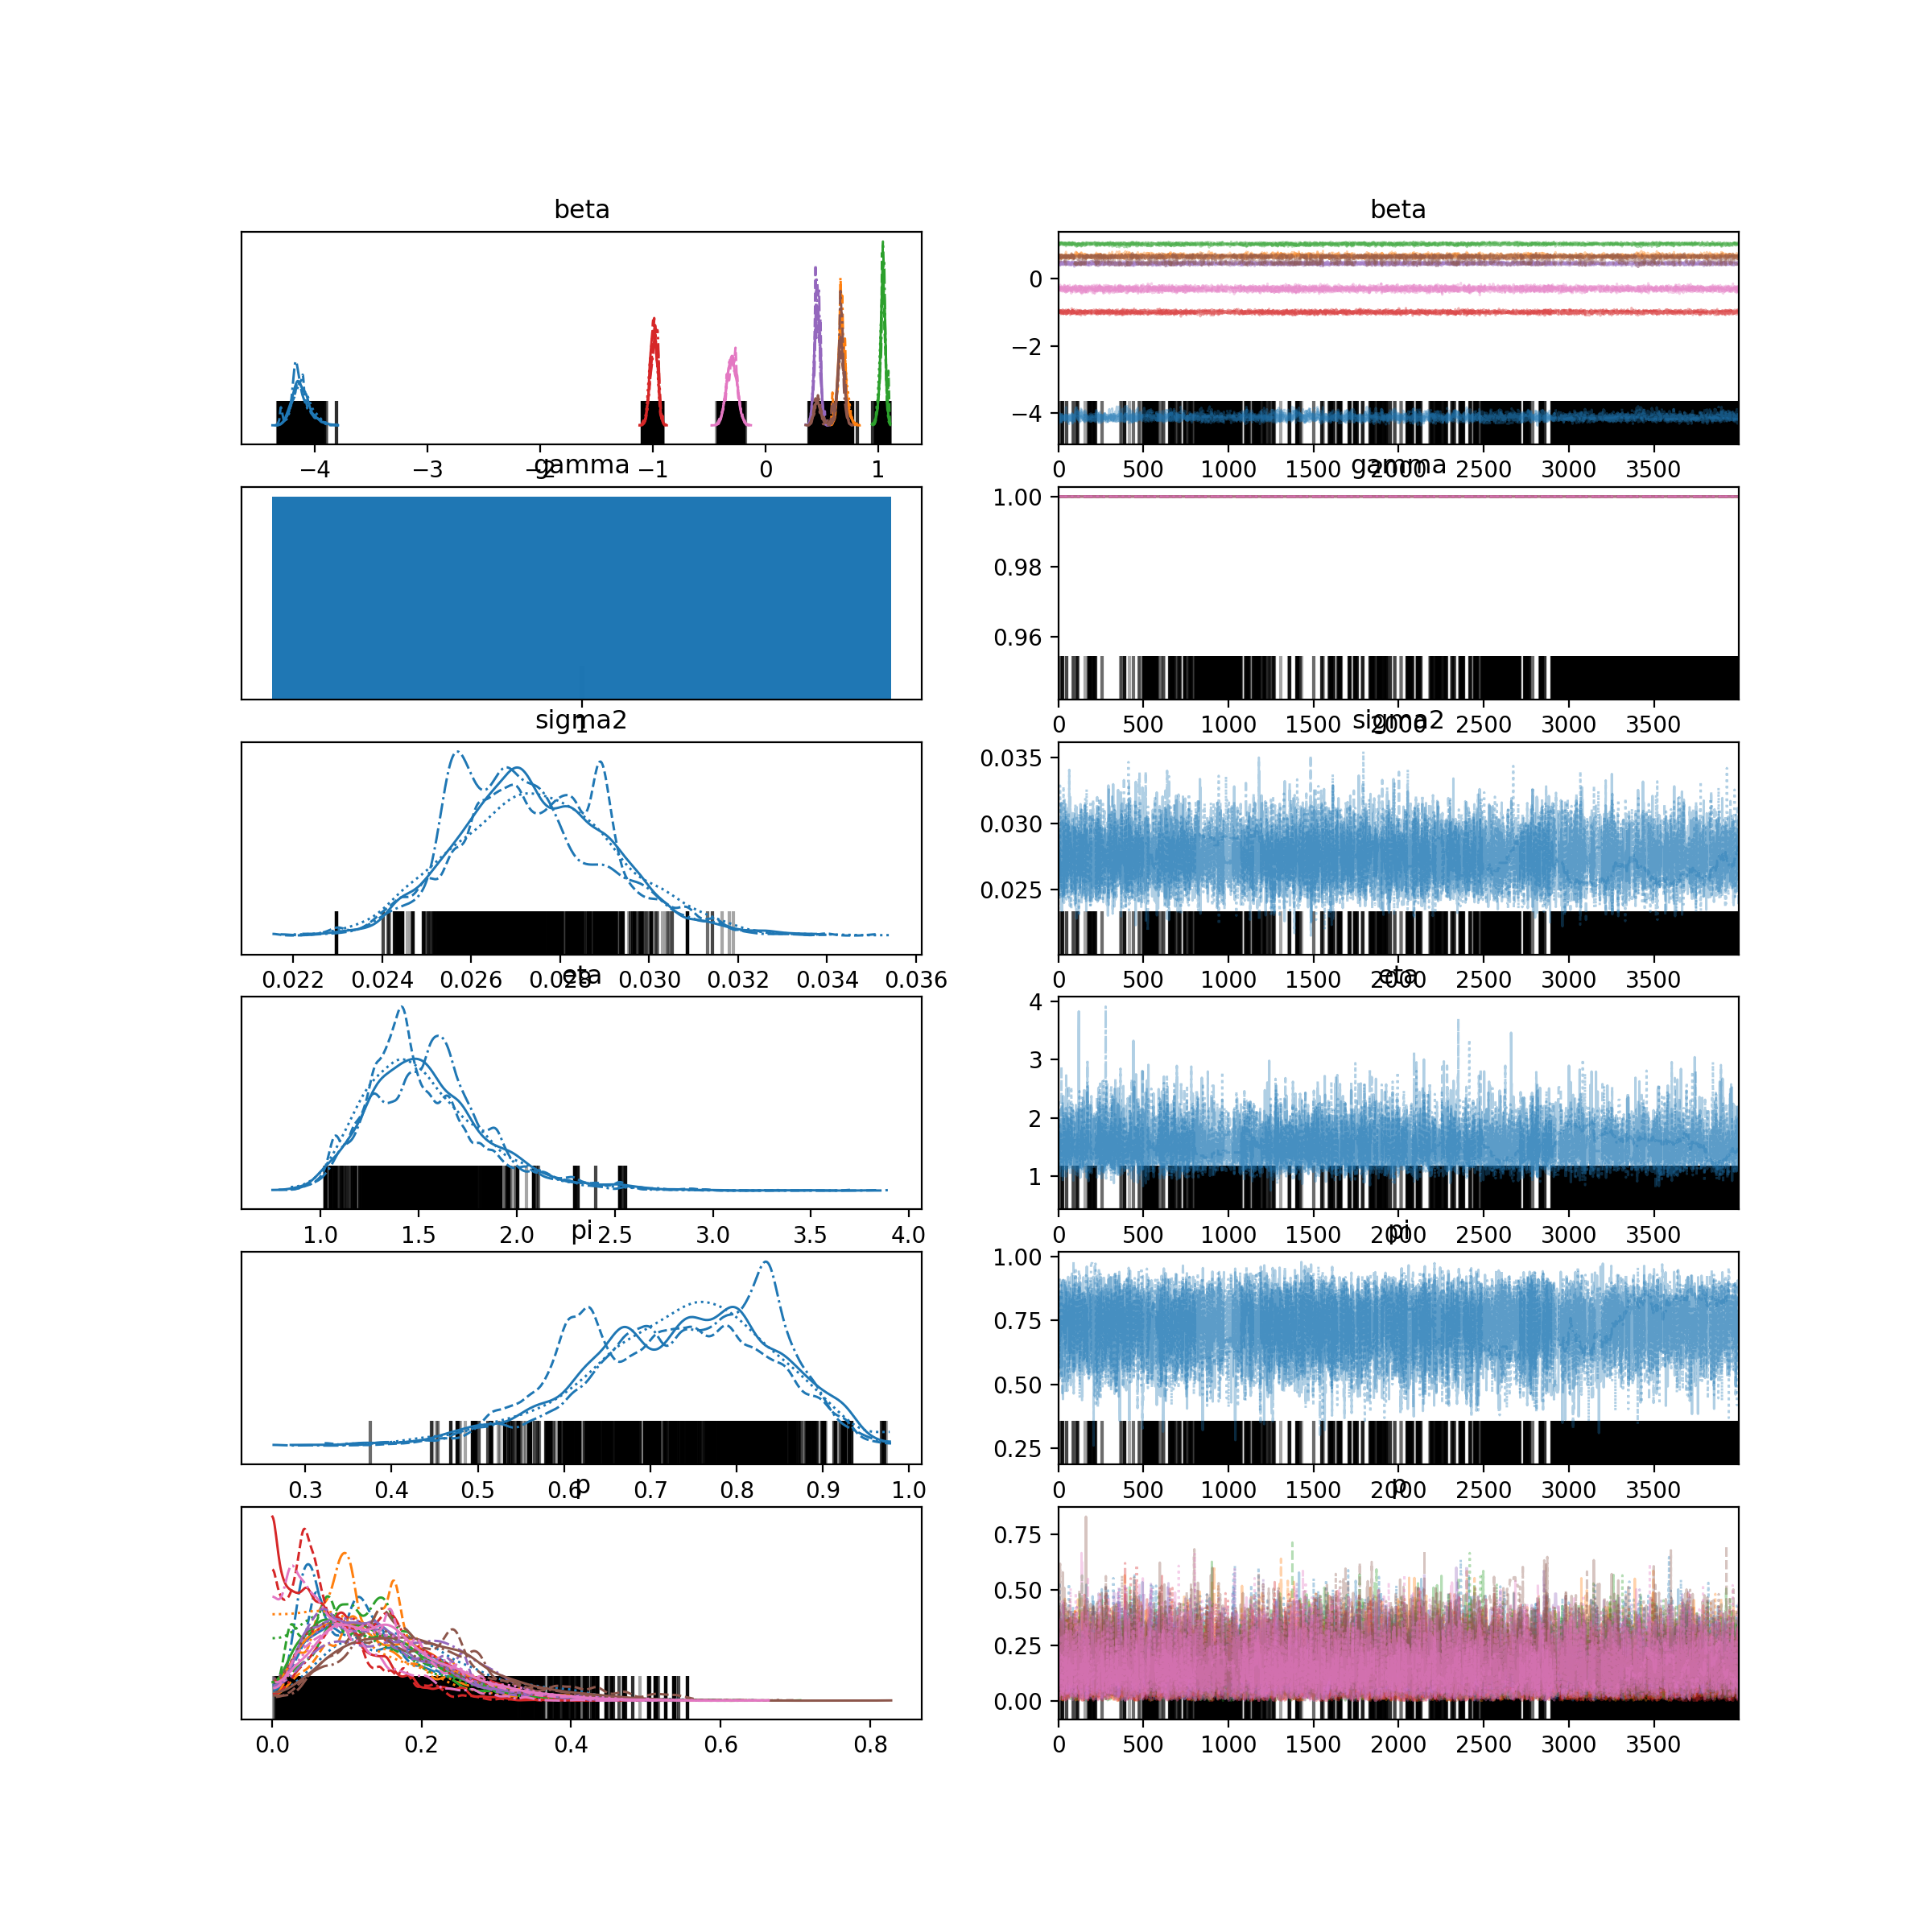

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  -4.121  0.082  -4.267   -3.944      0.005    0.004     232.0   
beta[1]   0.680  0.036   0.616    0.756      0.002    0.001     484.0   
beta[2]   1.040  0.023   0.991    1.085      0.001    0.001     553.0   
beta[3]  -0.990  0.033  -1.051   -0.932      0.003    0.002     155.0   
beta[4]   0.460  0.025   0.411    0.505      0.001    0.000    1605.0   
beta[5]   0.617  0.092   0.432    0.716      0.003    0.002     922.0   
beta[6]  -0.298  0.047  -0.389   -0.213      0.001    0.000    7014.0   
gamma[0]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[1]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[2]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[3]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[4]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[5]  1.000  0.000   1.000    1.000      0.000 

In [32]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 4000  # Number of samples
D = 7  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=1.0)  # Dirichlet prior concentration parameter
    #alpha=5
    p = pm.Dirichlet("p", a=pm.math.ones(7) * alpha, shape=7)  # Class probabilities

    S = pm.Categorical("S", p=p, shape=D)  # Class assignment for predictors (0-9)

    eta = pm.InverseGamma("eta", alpha=10.0, beta=10.0)  # Variance for beta_m
    beta_m = pm.Normal("beta_m", mu=0.0, sigma=eta, shape=7)  # Regression coefficients for each class

    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S

    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=4.0, beta=4.0)  # Probability of gamma=1
    gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=0.1, beta=0.1)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=1000, chains=4,step=pm.NUTS(target_accept=0.6,max_treedepth=15), return_inferencedata=True, cores=1)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
print(summary)

<IPython.core.display.Javascript object>


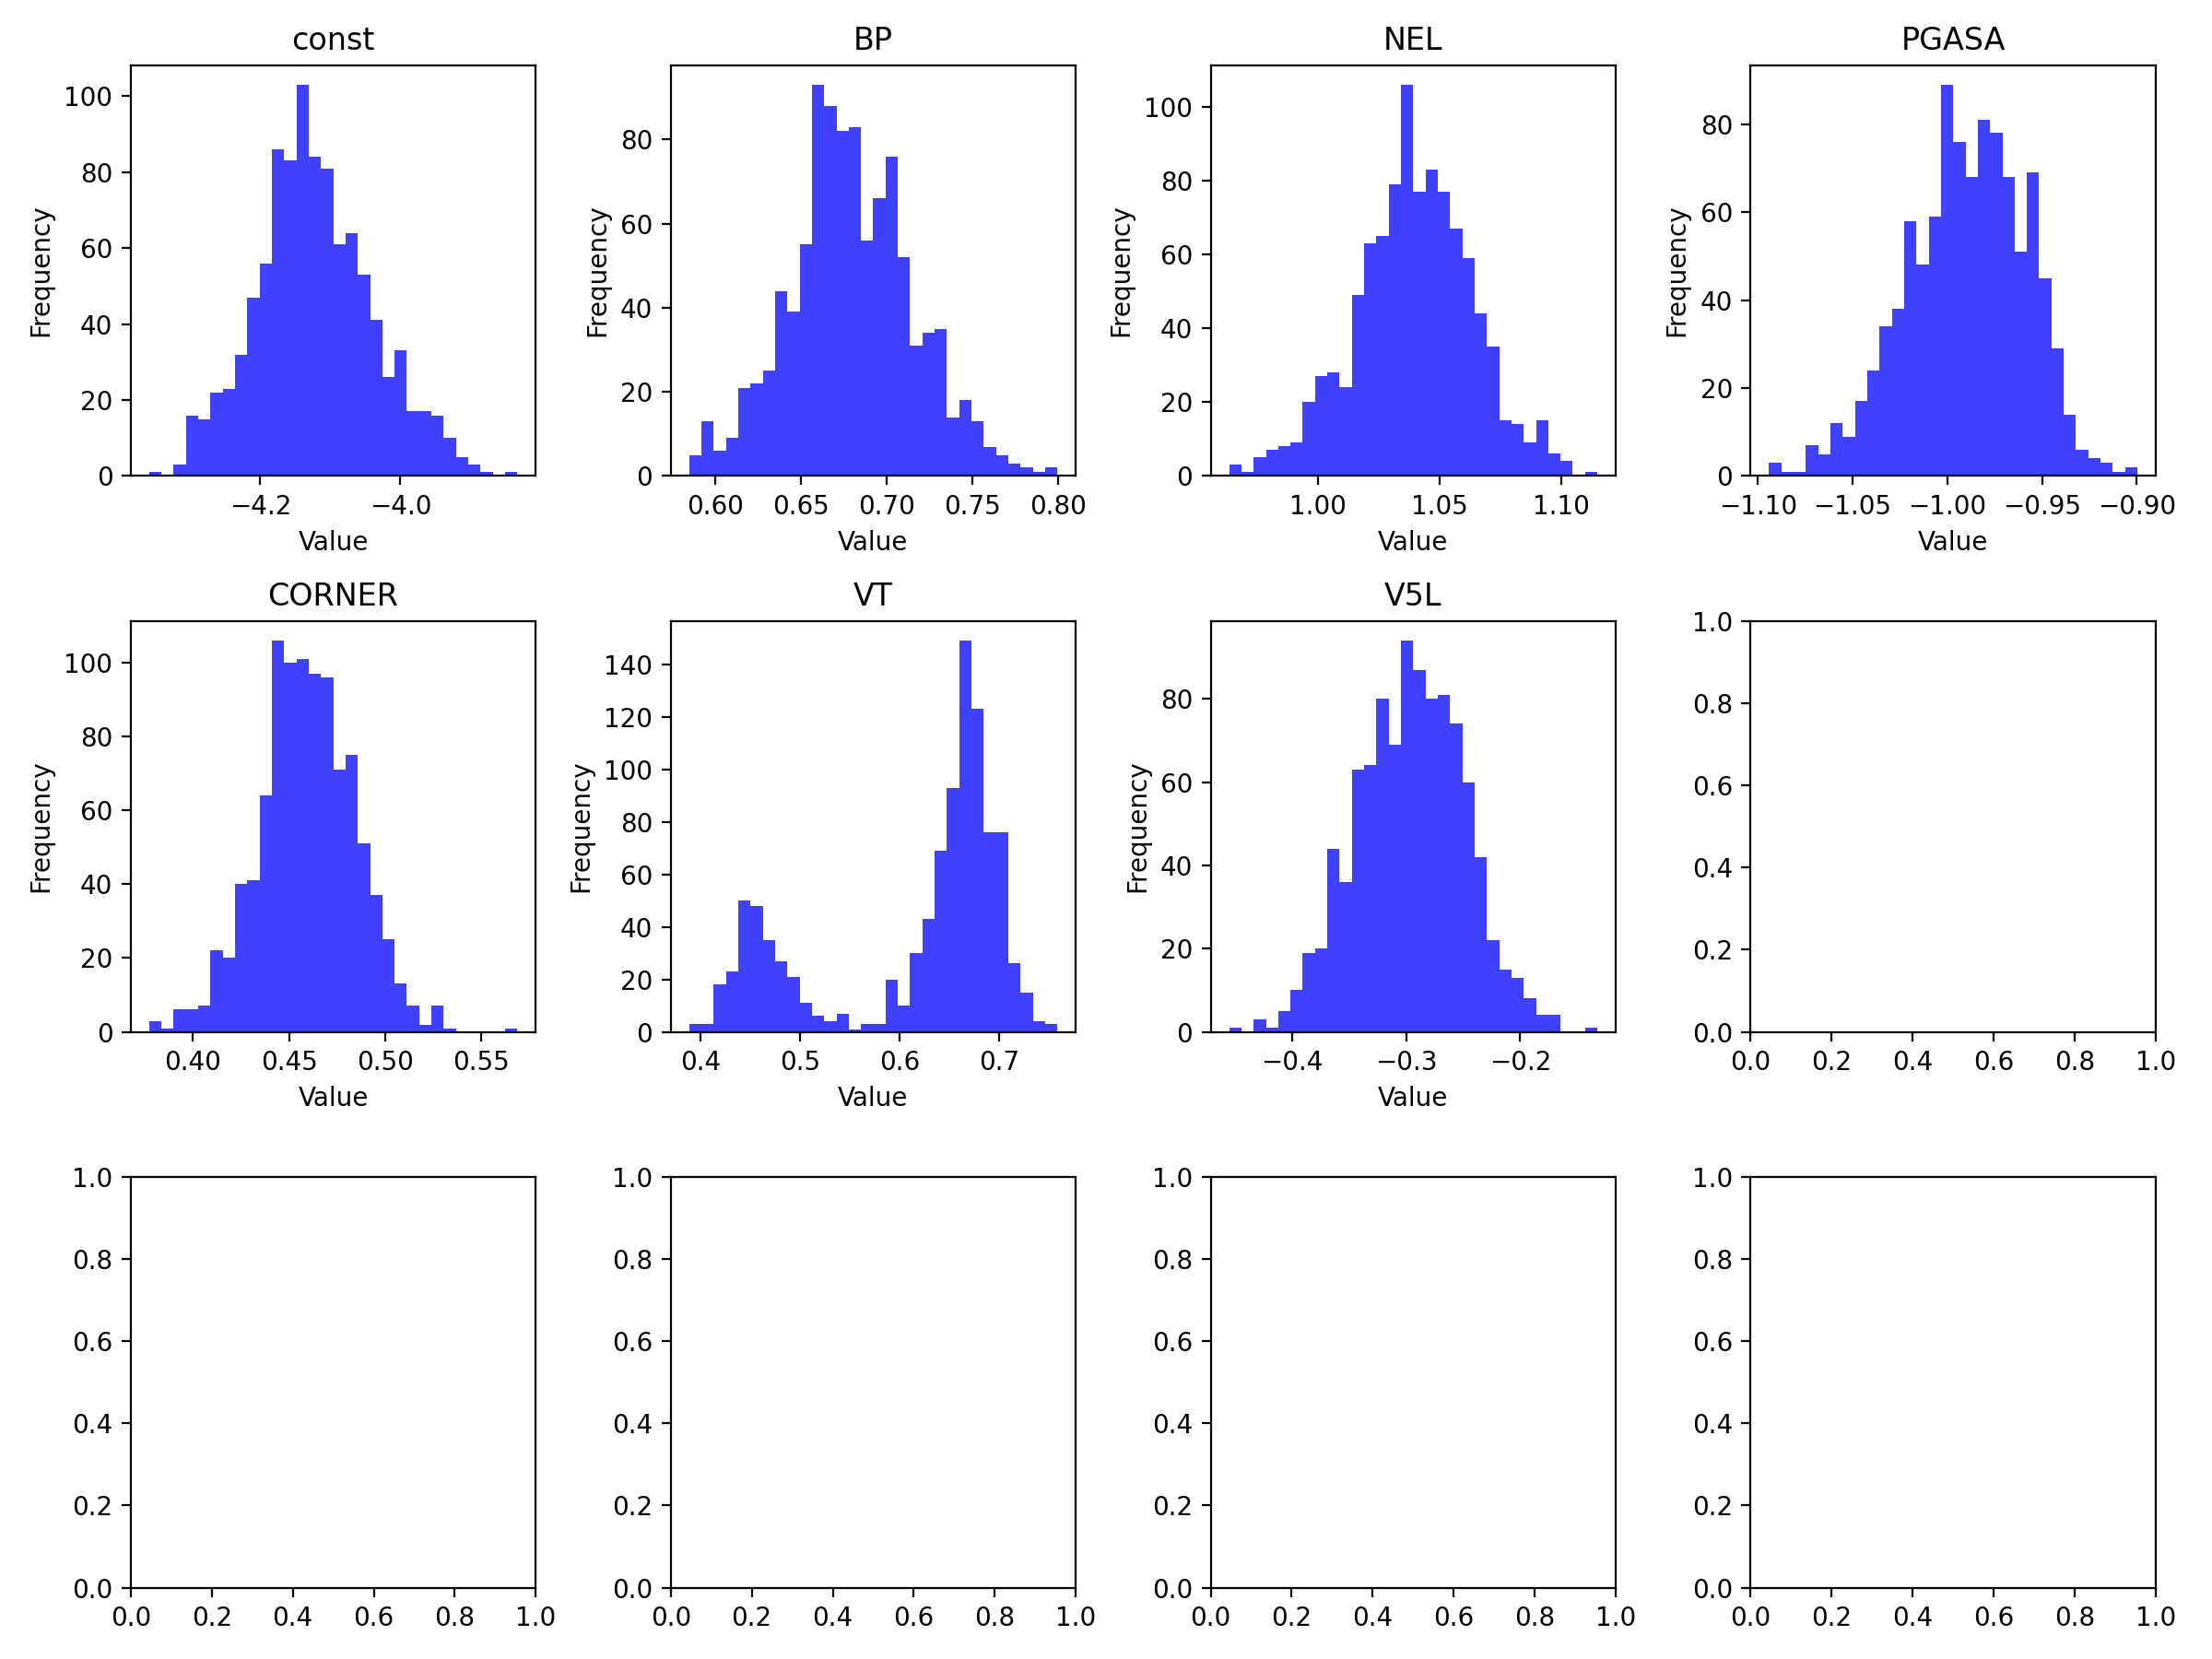

[1. 1. 1. 1. 1. 1. 1.]
[-4.12136305  0.67954293  1.03974458 -0.99000797  0.45953046  0.61429857
 -0.29598056]
[3.202 3.654 2.458 2.606 3.913 3.778 2.175]
1000 samples' R² values=: 0.9655


In [33]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))
axes = axes.flatten()

for i in range(7):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [27]:

trace.to_netcdf("my_trace_drop_LOWVT2.nc")

# 查看并保存summary
summary_df = az.summary(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
print(summary_df)
summary_df.to_csv("my_summary_LOWVT2.csv")

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  -4.112  0.086  -4.256   -3.937      0.003    0.002    1127.0   
beta[1]   0.683  0.037   0.615    0.755      0.001    0.001    1207.0   
beta[2]   1.038  0.025   0.987    1.080      0.001    0.001    1175.0   
beta[3]  -0.993  0.034  -1.057   -0.930      0.001    0.000    2800.0   
beta[4]   0.460  0.026   0.412    0.510      0.001    0.000    2452.0   
beta[5]   0.607  0.099   0.425    0.714      0.003    0.002    1268.0   
beta[6]  -0.300  0.048  -0.390   -0.211      0.001    0.001    3548.0   
gamma[0]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[1]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[2]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[3]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[4]  1.000  0.000   1.000    1.000      0.000    0.000   16000.0   
gamma[5]  1.000  0.000   1.000    1.000      0.000 

In [61]:
import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','BT','IP','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[df['SELEC2024'] == 1][columns_to_include].copy()
new_df = new_df[new_df['TOK'] == "AUG"]
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/new_df['SPLASMA']/2
# 显示新 DataFrame
print("New DataFrame:")
print(new_df)


columns_to_include_for_regre = ['BP','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BP','NEL','PGASA']] 
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
#x.drop([' VERTPLT','V5'], axis=1, inplace=True)
x.drop(["STANDARD",'Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','HT3R']].max(axis=1)
#x.drop(['HT3R','V5E','V5C','STANDARD'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

New DataFrame:
     TOK  SPLASMA     BT      IP   RGEO    PLTH   NEL  PGASA    DIVCON  \
77   AUG    44.56  2.883  1.0040  1.621  1.6600  4.50    2.0  STANDARD   
78   AUG    44.57  2.882  1.0030  1.619  1.6500  4.56    2.0  STANDARD   
79   AUG    44.70  2.883  0.9987  1.614  1.3000  4.77    2.0  STANDARD   
89   AUG    44.41  2.283  1.0000  1.634  1.5000  4.12    2.0  STANDARD   
90   AUG    44.40  2.284  0.9987  1.631  1.3000  4.04    2.0  STANDARD   
..   ...      ...    ...     ...    ...     ...   ...    ...       ...   
324  AUG    44.08  2.288  0.5993  1.621  0.8800  2.69    2.0  STANDARD   
325  AUG    43.98  2.482  0.7961  1.609  1.2500  4.79    2.0  STANDARD   
326  AUG    42.82  2.481  0.7967  1.623  1.1800  3.77    2.0  STANDARD   
327  AUG    42.89  2.976  0.7947  1.625  1.2310  3.70    2.0  STANDARD   
328  AUG    42.76  2.386  0.7952  1.626  0.9848  3.70    2.0  STANDARD   

           BP  PLTH/S/2  
77   0.288377  0.018627  
78   0.287670  0.018510  
79   0.284722  0.0

Sequential sampling (4 chains in 1 job)
CompoundStep
>NUTS: [alpha, p, eta, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma]


Output()

Output()

Output()

Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 111 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 230 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


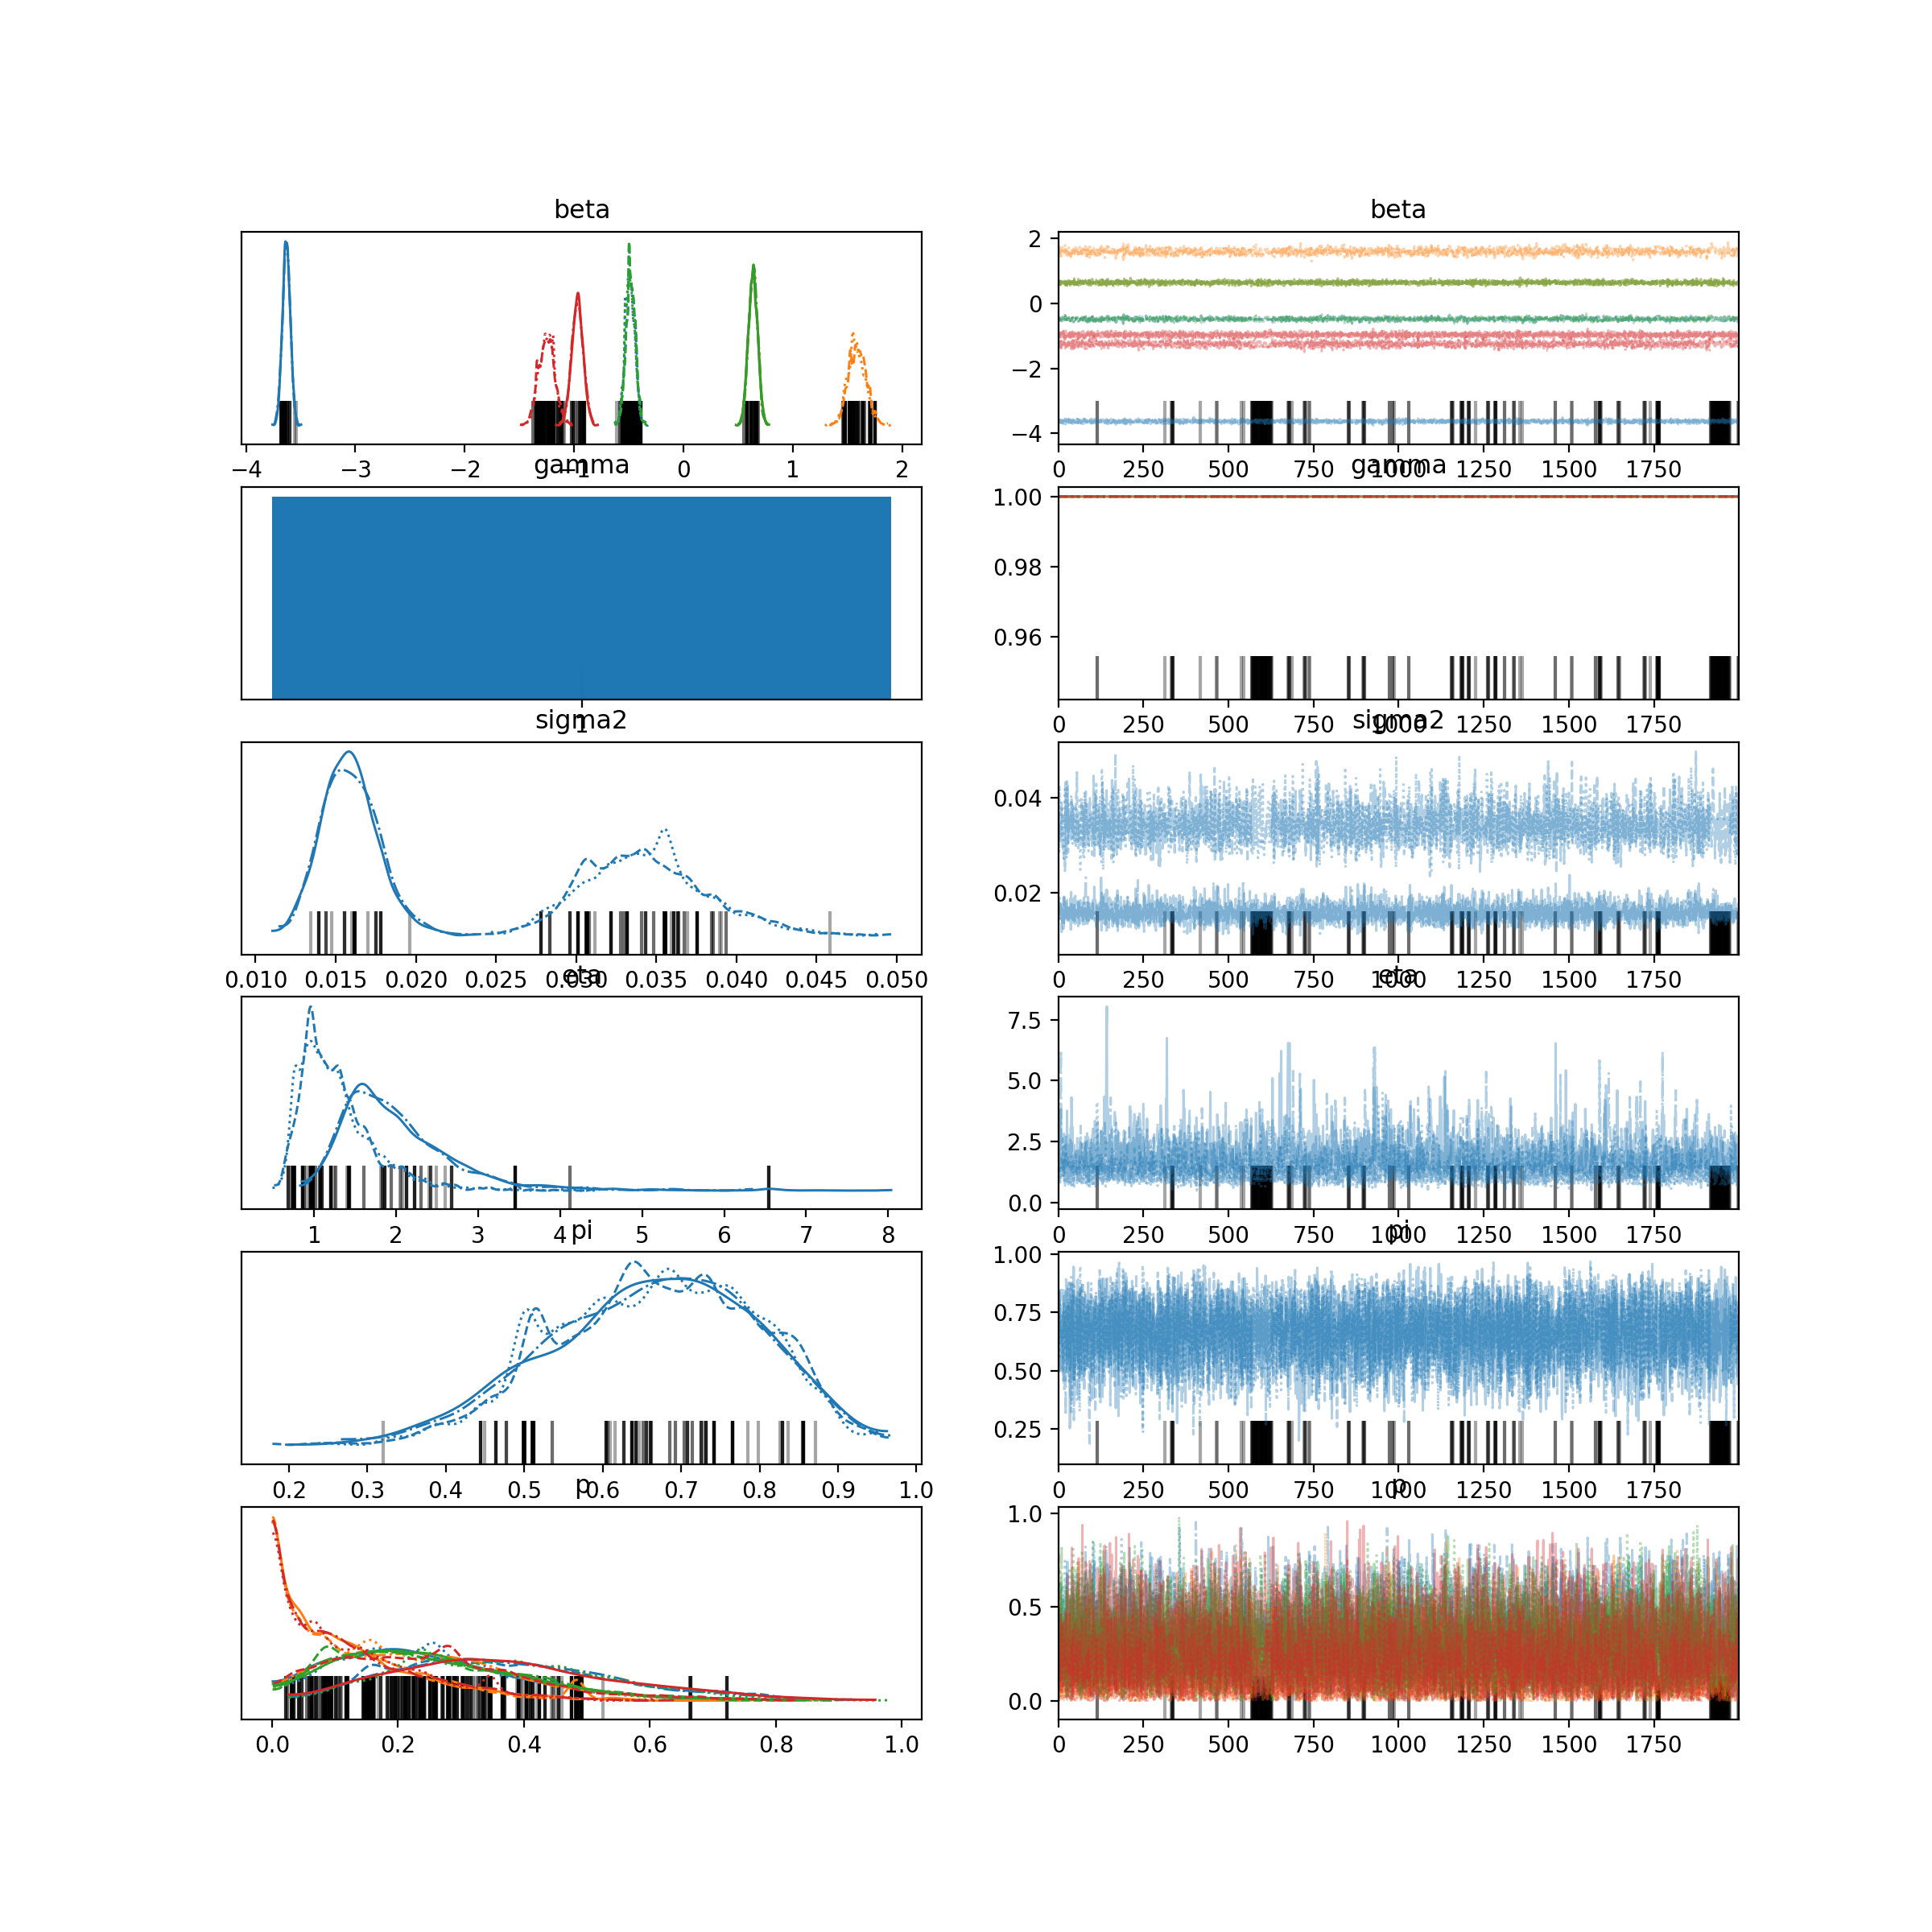

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  -2.059  1.573  -3.691   -0.425      0.785    0.601       6.0   
beta[1]   1.112  0.480   0.567    1.705      0.237    0.182       6.0   
beta[2]   0.075  0.563  -0.549    0.702      0.280    0.214       6.0   
beta[3]  -1.110  0.154  -1.358   -0.887      0.071    0.054       6.0   
gamma[0]  1.000  0.000   1.000    1.000      0.000    0.000    8000.0   
gamma[1]  1.000  0.000   1.000    1.000      0.000    0.000    8000.0   
gamma[2]  1.000  0.000   1.000    1.000      0.000    0.000    8000.0   
gamma[3]  1.000  0.000   1.000    1.000      0.000    0.000    8000.0   
sigma2    0.025  0.010   0.013    0.040      0.005    0.004       6.0   
eta       1.645  0.718   0.639    2.875      0.186    0.134      11.0   
pi        0.664  0.130   0.437    0.899      0.002    0.001    4871.0   
p[0]      0.310  0.171   0.008    0.612      0.030    0.022      31.0   
p[1]      0.188  0.147   0.000    0.457      0.031 

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


In [70]:

# Step 1: Generate simulated data
np.random.seed(22)
N = 2000  # Number of samples
D = 4  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=1.0)  # Dirichlet prior concentration parameter
    #alpha=5
    p = pm.Dirichlet("p", a=pm.math.ones(4) * alpha, shape=4)  # Class probabilities

    S = pm.Categorical("S", p=p, shape=D)  # Class assignment for predictors (0-9)

    eta = pm.InverseGamma("eta", alpha=4.0, beta=4.0)  # Variance for beta_m
    beta_m = pm.Normal("beta_m", mu=0.0, sigma=eta, shape=4)  # Regression coefficients for each class

    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S

    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=4.0, beta=4.0)  # Probability of gamma=1
    gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=0.1, beta=0.1)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.8,max_treedepth=15), return_inferencedata=True, cores=1)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
print(summary)

<IPython.core.display.Javascript object>


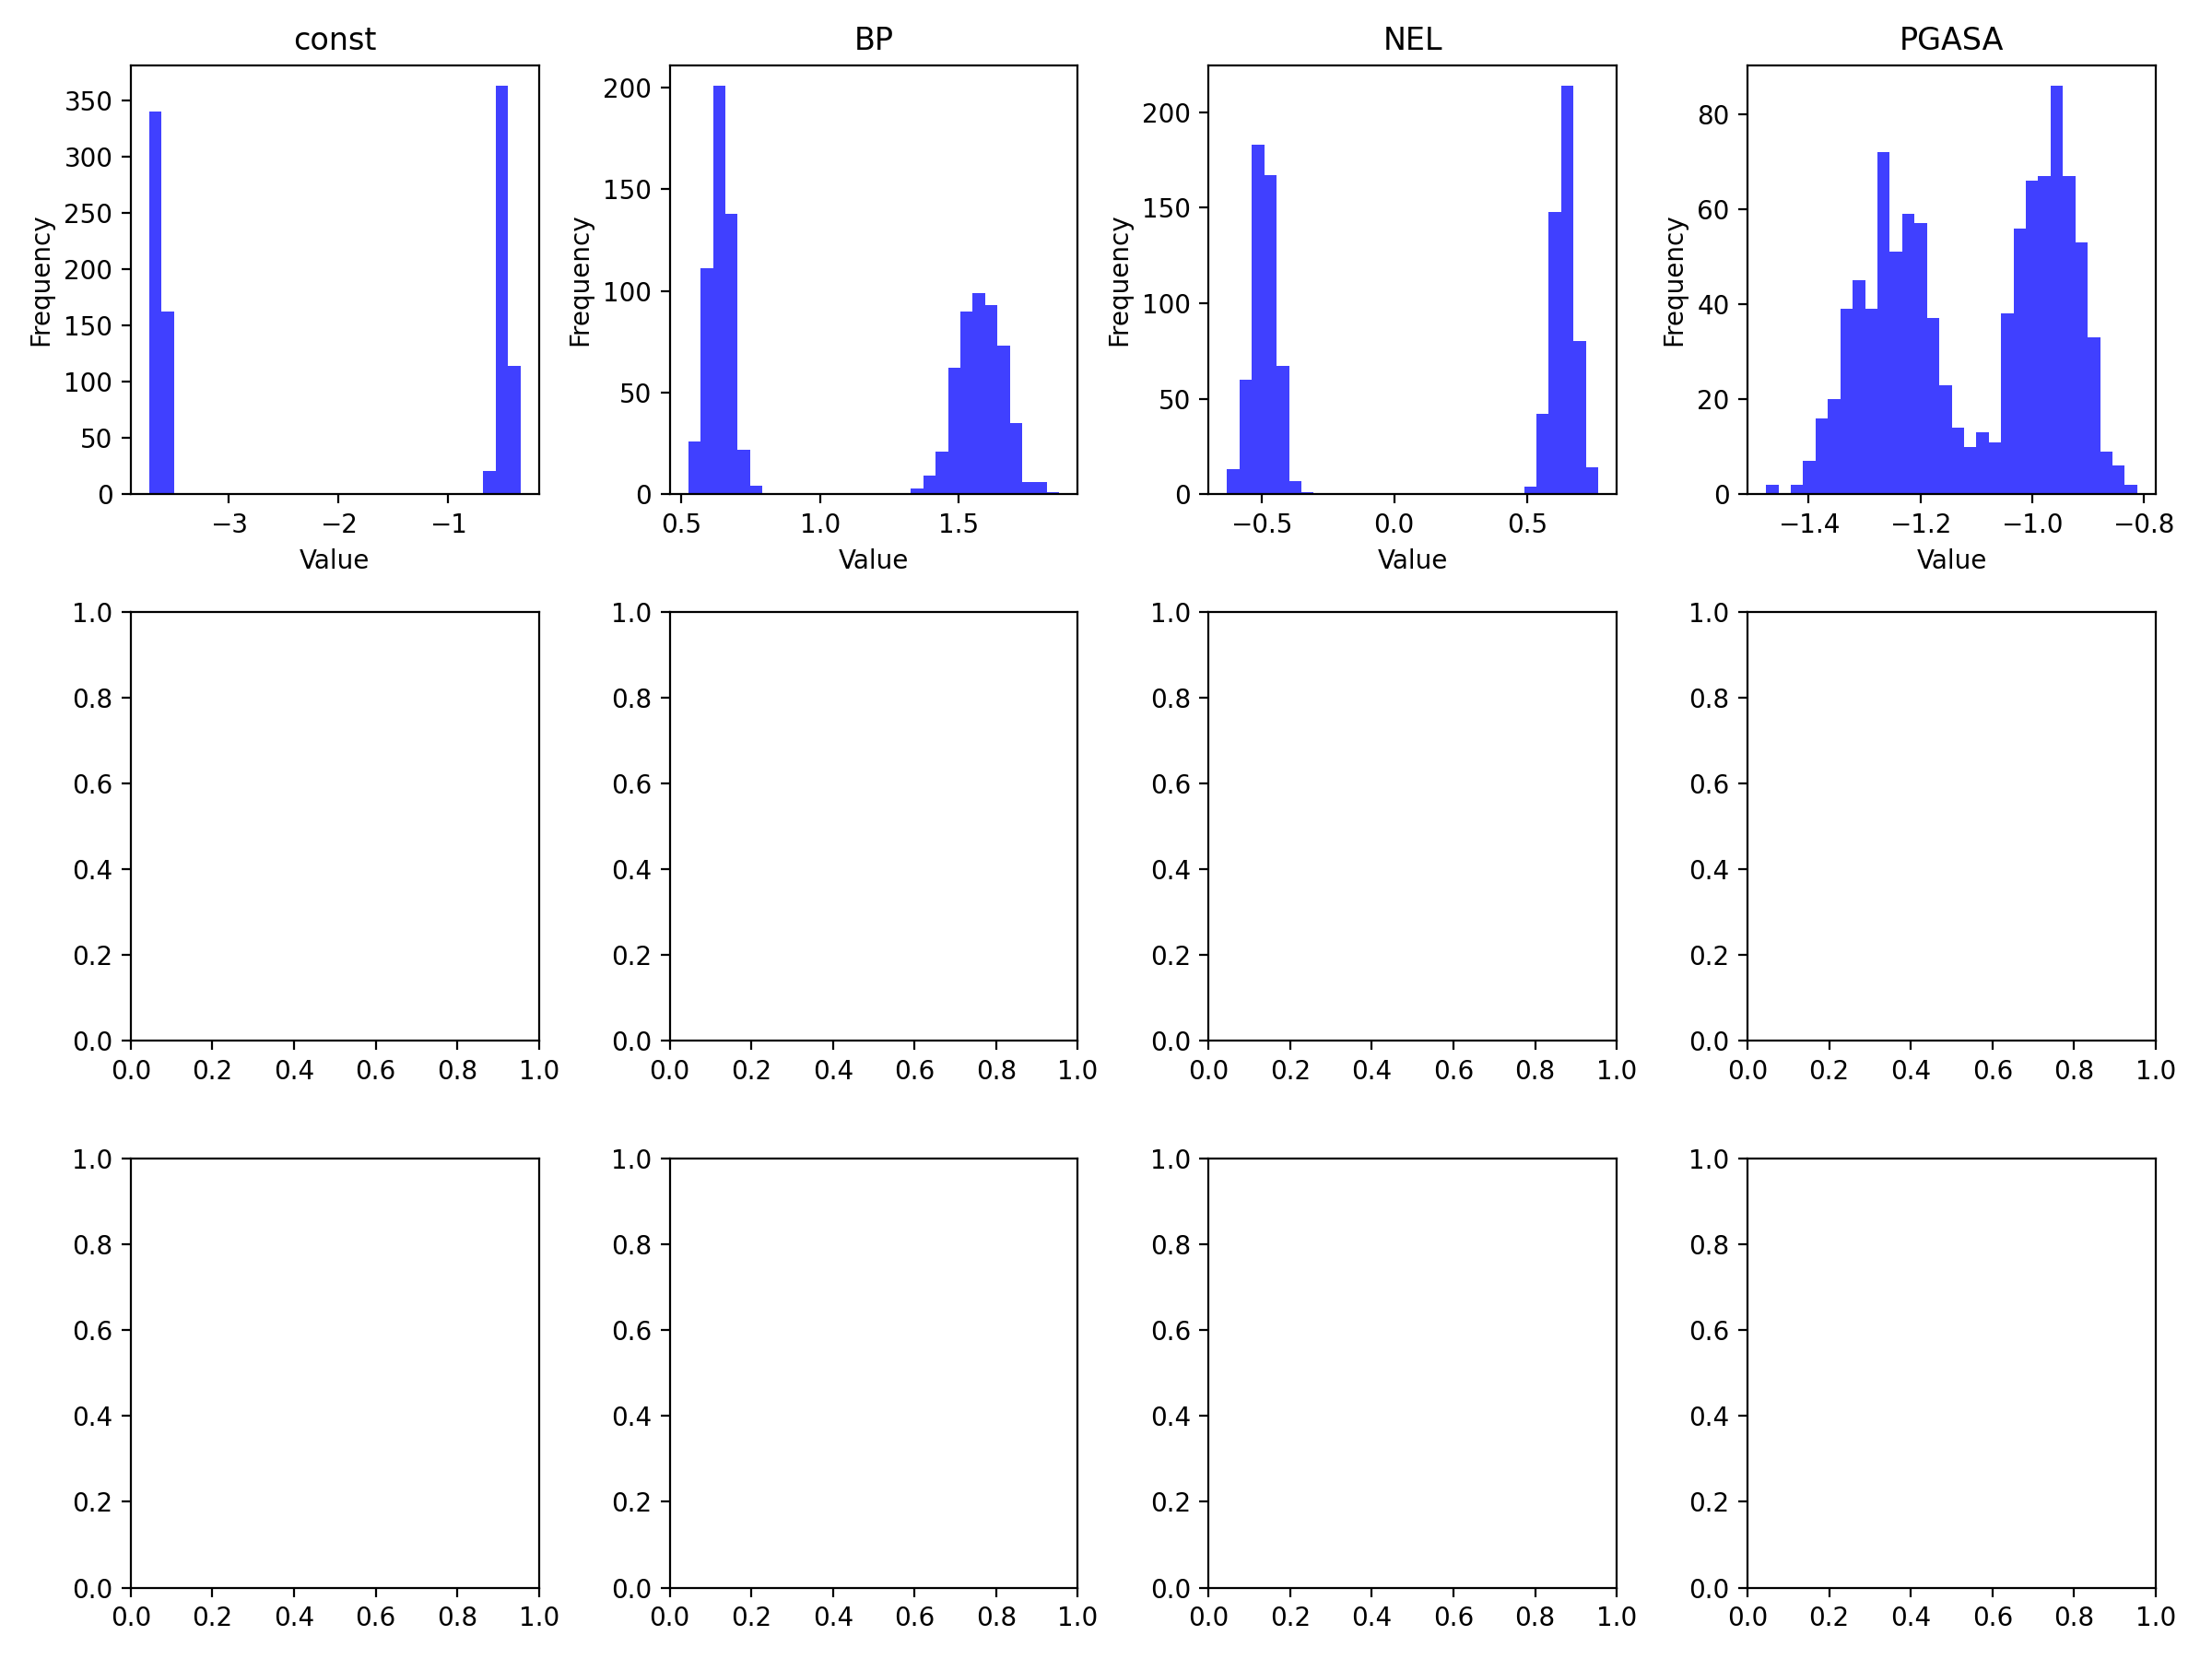

[1. 1. 1. 1.]
[-2.0674783   1.10729048  0.07670001 -1.10914197]
[0.765 1.507 1.292 1.731]
1000 samples' R² values=: 0.8134


In [72]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")